In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [19]:
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [20]:
# GPU 사용 가능 여부 확인
print(f"torch version : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch version : 2.2.2+cpu
Using device: cpu


In [21]:
def get_label(label):
    i = -1
    while(label[i].isdigit()):
        i -= 1
    return label[:i+1]

In [22]:
def get_dataset(csv_folder):
    label_dict = {'left':0, 'right':1, 'blink':2, 'none':3}
    # 데이터와 라벨 저장 리스트
    data = []
    labels = []

    # CSV 파일 읽기 및 정규화
    for file_name in os.listdir(csv_folder):
        if file_name.endswith('.csv'):
            file_path = os.path.join(csv_folder, file_name)

            # CSV 파일 읽기
            df = pd.read_csv(file_path, header=None, skiprows=1, dtype=float)  # 첫 번째 행은 헤더로 사용하지 않음

            # feature1 ~ feature20 추출
            features = df.iloc[:, :20].dropna(axis=0).values  # NaN 제거

            # # 0에서 1 사이로 정규화
            # min_vals = features.min(axis=0)
            # max_vals = features.max(axis=0)
            # normalized_features = 2 * (features - min_vals) / (max_vals - min_vals) - 1

            # 파일 이름을 라벨로 사용
            # label = file_name.split('_')[0]
            label = get_label(file_name.split('_')[0])

            # 데이터와 라벨 추가
            data.extend(features)
            labels.extend([label_dict[label]] * len(features))

    data = np.array(data, dtype=np.float32)  # 데이터 배열
    # 데이터와 라벨을 PyTorch 텐서로 변환
    data_tensor = torch.tensor(data, dtype=torch.float32) # 데이터 텐서
    labels_tensor = torch.tensor(labels, dtype=torch.long) # 라벨을 해시 값으로 변환

    print(f"데이터 크기: {data_tensor.shape}")
    print(f"라벨 크기: {labels_tensor.shape}")

    return data_tensor, labels_tensor

In [23]:
def make_dataset(csv_folder, need_test=True, concat=1):
    data_tensor, labels_tensor = get_dataset(csv_folder)
    if concat > 1:
        data_tensor = data_tensor.repeat(concat, 1)
        labels_tensor = labels_tensor.repeat(concat)
    # 1. TensorDataset 생성 및 셔플
    dataset = TensorDataset(data_tensor, labels_tensor)
    shuffled_indices = torch.randperm(len(dataset))
    shuffled_dataset = torch.utils.data.Subset(dataset, shuffled_indices)
    if need_test:
        # 2. 학습/테스트 분리
        train_size = int(0.8 * len(shuffled_dataset))
        test_size = len(shuffled_dataset) - train_size
        shuffled_dataset, _ = random_split(shuffled_dataset, [train_size, test_size])

    # 3. train 데이터만 추출해서 min, max 계산 (특성별)
    train_data = torch.stack([shuffled_dataset[i][0] for i in range(len(shuffled_dataset))])
    min_val = train_data.min()
    max_val = train_data.max()

    # 4. 전체 데이터에 -1~1 정규화 적용
    def minmax_scale(tensor, min_val, max_val):
        scale = (max_val - min_val)
        if scale == 0: # 0 나눗셈 방지
            scale = 1e-8
        return 2 * ((tensor - min_val) / scale) - 1

    with torch.no_grad():
        data_tensor = minmax_scale(data_tensor, min_val, max_val)

    # 5. TensorDataset 다시 생성
    dataset = TensorDataset(data_tensor, labels_tensor)
    if need_test:
        shuffled_indices = torch.randperm(len(dataset))
        shuffled_dataset = Subset(dataset, shuffled_indices)
        train_dataset, test_dataset = random_split(shuffled_dataset, [train_size, test_size])
        return train_dataset, test_dataset, min_val, max_val
    else:
        return dataset, min_val, max_val


In [2]:
# MLP 모델 정의
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # 입력층 -> 은닉층
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size) # 은닉층 -> 출력층

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


In [25]:
def train_model_with_kfold(train_dataset, test_dataset, input_size=20, hidden_size=16, output_size=4, batch_size=50, learning_rate=0.001, num_epochs=20, k_folds=10):
    # ======================================
    # 하이퍼파라미터 설정
    # ======================================
    early_stopping_patience = 5  # 조기 종료 기준
    criterion = nn.CrossEntropyLoss() # 손실 함수


    # ======================================
    # 교차 검증 설정
    # ======================================
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_train_accuracies = []
    fold_valid_accuracies = []

    # ======================================
    # K-Fold 학습 루프
    # ======================================
    for fold, (train_idx, valid_idx) in enumerate(kf.split(train_dataset)):
        print(f"\n===== Fold {fold + 1}/{k_folds} =====")

        # 매 Fold마다 모델, 옵티마이저 재생성
        model = MLP(input_size, hidden_size, output_size).to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        # 데이터 분리
        train_subset = Subset(train_dataset, train_idx)
        valid_subset = Subset(train_dataset, valid_idx)
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_subset, batch_size=batch_size, shuffle=False)

        # 손실 추적용
        best_valid_loss = float("inf")
        patience_counter = 0

        # Epoch 루프
        for epoch in range(num_epochs):
            # ========== 학습 단계 ==========
            model.train()
            total_train, correct_train, train_loss_sum = 0, 0, 0.0

            for batch_data, batch_labels in train_loader:
                batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

                optimizer.zero_grad()
                outputs = model(batch_data)
                loss = criterion(outputs, batch_labels)
                loss.backward()
                optimizer.step()

                train_loss_sum += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_train += batch_labels.size(0)
                correct_train += (predicted == batch_labels).sum().item()

            train_loss = train_loss_sum / len(train_loader)
            train_accuracy = 100 * correct_train / total_train

            # ========== 검증 단계 ==========
            model.eval()
            total_valid, correct_valid, valid_loss_sum = 0, 0, 0.0
            with torch.no_grad():
                for batch_data, batch_labels in valid_loader:
                    batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
                    outputs = model(batch_data)
                    loss = criterion(outputs, batch_labels)
                    valid_loss_sum += loss.item()

                    _, predicted = torch.max(outputs, 1)
                    total_valid += batch_labels.size(0)
                    correct_valid += (predicted == batch_labels).sum().item()

            valid_loss = valid_loss_sum / len(valid_loader)
            valid_accuracy = 100 * correct_valid / total_valid

            print(f"Epoch {epoch + 1}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_accuracy:.2f}% | "
                  f"Val Loss: {valid_loss:.4f}, Acc: {valid_accuracy:.2f}%")

            # 조기 종료(Early Stopping)
            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                patience_counter = 0
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print("Early stopping triggered.")
                    break

        # fold별 성능 저장
        fold_train_accuracies.append(train_accuracy)
        fold_valid_accuracies.append(valid_accuracy)

    # ======================================
    # 교차 검증 평균 성능 출력
    # ======================================
    print("\n===== Cross Validation Results =====")
    print(f"Average Train Accuracy: {np.mean(fold_train_accuracies):.2f}% ± {np.std(fold_train_accuracies):.2f}")
    print(f"Average Valid Accuracy: {np.mean(fold_valid_accuracies):.2f}% ± {np.std(fold_valid_accuracies):.2f}")

    # ======================================
    # 최종 Test 성능 평가
    # ======================================
    print("\n===== Final Test Evaluation =====")
    best_model = MLP(input_size, hidden_size, output_size).to(device)
    best_model.load_state_dict(best_model_state)
    best_model.eval()

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    total_test, correct_test = 0, 0
    with torch.no_grad():
        for batch_data, batch_labels in test_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
            outputs = best_model(batch_data)
            _, predicted = torch.max(outputs, 1)
            total_test += batch_labels.size(0)
            correct_test += (predicted == batch_labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    print(f"Test Accuracy: {test_accuracy:.2f}%")

    return best_model


In [26]:
def fine_tune_model(model, dataset, batch_size=50, learning_rate=0.003, num_epochs=5):
    # ======================================
    # 하이퍼파라미터 설정
    # ======================================
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss() # 손실 함수
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) # 옵티마이저

    # ======================================
    # 모델 학습
    # ======================================
    for epoch in range(num_epochs):
        # ========== 학습 단계 ==========
        model.train()
        total_data, correct_data, loss_sum = 0, 0, 0.0

        for batch_data, batch_labels in data_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

            optimizer.zero_grad()
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_data += batch_labels.size(0)
            correct_data += (predicted == batch_labels).sum().item()

        loss = loss_sum / len(data_loader)
        accuracy = 100 * correct_data / total_data
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {loss:.4f}, Accuracy: {accuracy:.2f}%")

    # ======================================
    # 최종 Test 성능 평가
    # ======================================
    print("\n===== Final Test Evaluation =====")
    model.eval()
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    total_test, correct_test = 0, 0
    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
            outputs = model(batch_data)
            _, predicted = torch.max(outputs, 1)
            total_test += batch_labels.size(0)
            correct_test += (predicted == batch_labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    print(f"Test Accuracy: {test_accuracy:.2f}%")



In [27]:
train_dataset, test_dataset, min_val, max_val = make_dataset('jaeheon_csv_new/')
model = train_model_with_kfold(train_dataset, test_dataset, learning_rate=0.001, num_epochs=20)

데이터 크기: torch.Size([872, 20])
라벨 크기: torch.Size([872])

===== Fold 1/10 =====
Epoch 1/20 | Train Loss: 1.4236, Acc: 24.24% | Val Loss: 1.3729, Acc: 32.86%
Epoch 2/20 | Train Loss: 1.3802, Acc: 25.20% | Val Loss: 1.3492, Acc: 35.71%
Epoch 3/20 | Train Loss: 1.3482, Acc: 38.44% | Val Loss: 1.3263, Acc: 61.43%
Epoch 4/20 | Train Loss: 1.3157, Acc: 50.88% | Val Loss: 1.2966, Acc: 62.86%
Epoch 5/20 | Train Loss: 1.2831, Acc: 63.64% | Val Loss: 1.2662, Acc: 70.00%
Epoch 6/20 | Train Loss: 1.2447, Acc: 72.09% | Val Loss: 1.2275, Acc: 68.57%
Epoch 7/20 | Train Loss: 1.2090, Acc: 71.93% | Val Loss: 1.1811, Acc: 72.86%
Epoch 8/20 | Train Loss: 1.1670, Acc: 73.05% | Val Loss: 1.1386, Acc: 74.29%
Epoch 9/20 | Train Loss: 1.1241, Acc: 74.64% | Val Loss: 1.0890, Acc: 74.29%
Epoch 10/20 | Train Loss: 1.0870, Acc: 74.32% | Val Loss: 1.0415, Acc: 74.29%
Epoch 11/20 | Train Loss: 1.0402, Acc: 74.16% | Val Loss: 0.9976, Acc: 72.86%
Epoch 12/20 | Train Loss: 1.0026, Acc: 73.84% | Val Loss: 0.9556, Acc: 74

In [13]:
dataset, min_val, max_val = make_dataset('jaeheon_csv_new/', need_test=False, concat=1)
fine_tune_model(model, dataset, learning_rate=0.003, num_epochs=10)

데이터 크기: torch.Size([232, 20])
라벨 크기: torch.Size([232])
Epoch [1/10] - Loss: 0.2531, Accuracy: 87.50%
Epoch [2/10] - Loss: 0.2196, Accuracy: 88.79%
Epoch [3/10] - Loss: 0.1887, Accuracy: 91.81%
Epoch [4/10] - Loss: 0.1817, Accuracy: 92.24%
Epoch [5/10] - Loss: 0.1603, Accuracy: 93.53%
Epoch [6/10] - Loss: 0.1478, Accuracy: 94.83%
Epoch [7/10] - Loss: 0.1445, Accuracy: 96.55%
Epoch [8/10] - Loss: 0.1271, Accuracy: 96.55%
Epoch [9/10] - Loss: 0.1171, Accuracy: 96.98%
Epoch [10/10] - Loss: 0.1109, Accuracy: 97.41%

===== Final Test Evaluation =====
Test Accuracy: 97.84%


In [ ]:
from torchviz import make_dot
from torch.autograd import Variable
x = Variable(torch.randn(1, 20))
make_dot(model(x), params=dict(model.named_parameters())).render("model2_3jh", format="png")

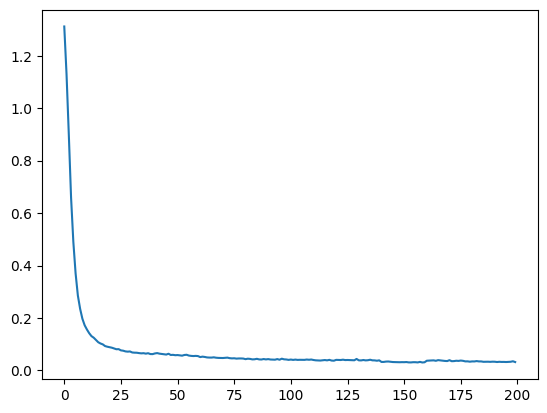

In [10]:
# 학습 손실 시각화
plt.plot(train_losses, label='Train Loss')

데이터 크기: torch.Size([232, 20])
라벨 크기: torch.Size([232])
Accuracy: 96.55%


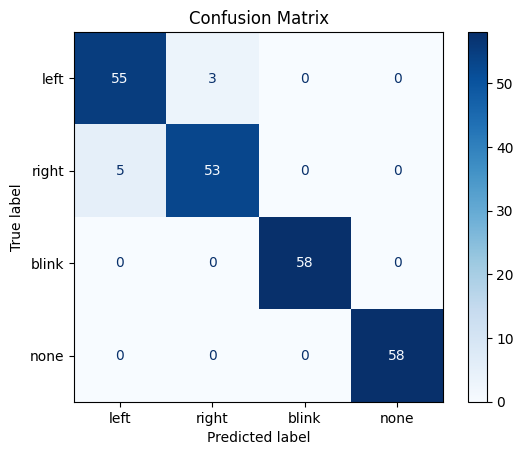

In [24]:
label_dict = {'left':0, 'right':1, 'blink':2, 'none':3}
# 모델 평가 및 혼동행렬 생성
model.eval()
all_preds = []
all_labels = []
dataset, _, __ = make_dataset('jaeheon_csv_new/', need_test=False)
test_dataloader = DataLoader(dataset, batch_size=20, shuffle=False)
with torch.no_grad():
    for batch_data, batch_labels in test_dataloader:
        batch_data = batch_data
        batch_labels = batch_labels
        outputs = model(batch_data)
        softmax_outputs = nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(softmax_outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(batch_labels.numpy())

# 혼동행렬 계산
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_dict.keys()))
correct = 0
total = 0
for i in range(len(all_labels)):
    if all_labels[i] == all_preds[i]:
        correct += 1 
    total += 1
print(f"Accuracy: {correct / total * 100:.2f}%")
# 혼동행렬 시각화
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [28]:
# 모델 저장
model_path = 'model2_3_jh_just_new.pth'
torch.save(model.state_dict(), model_path)
torch.save({'min_val': min_val, 'max_val': max_val}, 'norm_params2_3_jh_just_new.pth')
print(f"Model saved to {model_path}")


Model saved to model2_3_jh_just_new.pth


In [4]:
model = MLP(20, 16, 4)
dummy_input = torch.randn(1, 20)  # batch_size=1, 입력차원=20
torch.onnx.export(
    model, 
    dummy_input, 
    "model2_3.onnx",
    input_names=["Input"], 
    output_names=["Output"]
)

In [50]:
from torch.distributed.checkpoint import load_state_dict
model_path = 'model_save/model.pth'
print(torch.load(model_path)['fc2.bias'].type(torch.float32).flatten().numpy())

[-1.0271516  -0.18323389 -0.21591699]


In [ ]:
#모델 불러오기
model = MLP(input_size, hidden_size, output_size)
model.load_state_dict(torch.load(model_path))

In [53]:
file_name = 'weights/input_weight.txt'

s = open(file_name, 'r').read()
s = s.replace('\n', '')
while s.find('  ') != -1:
    s = s.replace('  ', ' ')
print(s)
open(file_name, 'w').write(s)

-2.6055727e+00 6.8342274e-01 -4.9750397e-01 -8.6169004e-02 -1.8872234e+00 1.4133153e+00 5.1553530e-01 1.1402611e+00 -1.4020022e+00 6.5075114e-02 -1.9556146e+00 1.7580350e-01 -8.3135408e-01 6.1522144e-01 -4.4781849e-01 2.1797206e-01 -9.9089724e-01 1.1924727e+00 -7.7540791e-01 2.9212266e-01 -7.5120902e-01 -1.4103316e-01 -1.0362312e+00 -6.2405550e-01 -1.8653132e+00 1.0715288e+00 -7.6060569e-01 4.8288608e-01 -1.7141314e+00 1.2059764e+00 1.4130991e+00 7.3915952e-01 -1.3688737e+00 4.0229088e-01 4.9674258e-01 8.2951331e-01 -1.1190417e+00 4.7926283e-01 5.2313179e-01 3.2087633e-01 5.7850605e-01 4.7293967e-01 5.1966769e-01 6.7650929e-02 1.4426445e+00 2.6191884e-01 -2.4932660e-01 -5.8637518e-01 1.4772362e+00 -3.3356389e-01 -1.1116889e+00 -2.4890420e-01 4.3551299e-01 3.7236130e-01 9.4676667e-01 1.7911130e-01 5.4327744e-01 -4.2204607e-01 1.1602383e+00 7.1371630e-02 1.4887962e+00 5.0866997e-01 1.2502234e+00 1.4558001e+00 -3.8430262e-01 2.0949922e+00 -3.4290764e-01 -6.0936999e-01 -1.5217481e+00 -5.30

2887